In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("my_data.csv")
print("dataset loaded successfully")


dataset loaded successfully


In [6]:
# 3. Basic Dataset Information
# ============================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nData Types:")
print(df.dtypes)


First 5 Rows:
        name    city  gender profession   age  cgpa  placed
0  moriarity     NaN  female        phd  28.0  5.94       1
1  moriarity  asgard     NaN   bachelor  50.0  8.55       0
2     holmes     NaN  female    masters  18.0  5.56       0
3        sam     NaN    male   bachelor  25.0  8.57       1
4        sam     NaN    male   bachelor  19.0  8.76       1

Last 5 Rows:
           name     city gender profession   age  cgpa  placed
1095     holmes      NaN   male    masters  26.0  8.92       1
1096  moriarity  wakanda   male    masters  19.0  9.01       0
1097        sam   asgard   male   bachelor  30.0  7.88       0
1098       dean   gotham   male    masters  28.0   NaN       1
1099        sam   asgard    NaN    masters  24.0  8.94       1

Dataset Shape:
(1100, 7)

Column Names:
Index(['name', 'city', 'gender', 'profession', 'age', 'cgpa', 'placed'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data co


Missing Values Count:
name           91
city          195
gender        106
profession    179
age           118
cgpa          138
placed          0
dtype: int64

Missing Values Percentage:
name           8.272727
city          17.727273
gender         9.636364
profession    16.272727
age           10.727273
cgpa          12.545455
placed         0.000000
dtype: float64


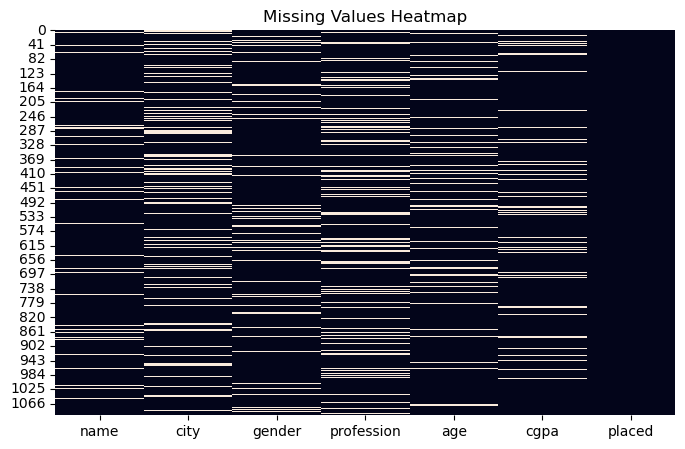

In [7]:
# 4. Check Missing Values
# ============================================================

print("\nMissing Values Count:")
print(df.isnull().sum())

print("\nMissing Values Percentage:")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

# Missing values graph
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [9]:
 #5. Check Duplicate Values
# ============================================================

print("\nDuplicate Rows Count:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nShape After Removing Duplicates:")
print(df.shape)



Duplicate Rows Count:
65

Shape After Removing Duplicates:
(1035, 7)


In [10]:
# 6. Clean Text Data
# ============================================================

# Remove extra spaces and convert text to lowercase
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.lower()

print("\nData After Cleaning Text:")
print(df.head())


Data After Cleaning Text:
        name    city  gender profession   age  cgpa  placed
0  moriarity     NaN  female        phd  28.0  5.94       1
1  moriarity  asgard     NaN   bachelor  50.0  8.55       0
2     holmes     NaN  female    masters  18.0  5.56       0
3        sam     NaN    male   bachelor  25.0  8.57       1
4        sam     NaN    male   bachelor  19.0  8.76       1


In [11]:
# 7. Handle Missing Values
# ============================================================

# Fill categorical missing values with mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numerical missing values with median
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing Values After Treatment:")
print(df.isnull().sum())


Missing Values After Treatment:
name          0
city          0
gender        0
profession    0
age           0
cgpa          0
placed        0
dtype: int64


C:\Users\kendr\AppData\Local\Temp\ipykernel_32292\4062896511.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\kendr\AppData\Local\Temp\ipykernel_32292\4062896511.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [12]:
# 8. Statistical Summary
# ============================================================

print("\nStatistical Summary of Numerical Columns:")
print(df.describe())

print("\nStatistical Summary of Categorical Columns:")
print(df.describe(include="object"))


Statistical Summary of Numerical Columns:
               age         cgpa       placed
count  1035.000000  1035.000000  1035.000000
mean     28.370048     7.606464     0.496618
std       8.855889     1.426599     0.500230
min      18.000000     4.010000     0.000000
25%      22.000000     7.260000     0.000000
50%      26.000000     7.890000     0.000000
75%      30.000000     8.640000     1.000000
max      50.000000     9.490000     1.000000

Statistical Summary of Categorical Columns:
             name     city gender profession
count        1035     1035   1035       1035
unique          8        4      2          3
top     moriarity  wakanda   male   bachelor
freq          346      548    814        659


In [13]:
# 9. Unique Values in Each Column
# ============================================================

print("\nUnique Values in Each Column:")
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())



Unique Values in Each Column:

name:
['moriarity' 'holmes' 'sam' 'bobby' 'castiel' 'sherlock' 'watson' 'dean']

city:
['wakanda' 'asgard' 'purgatory' 'gotham']

gender:
['female' 'male']

profession:
['phd' 'bachelor' 'masters']

age:
[28. 50. 18. 25. 19. 20. 26. 48. 22. 27. 21. 43. 29. 30. 23. 42. 44. 46.
 24. 41. 47. 40. 45. 49.]

cgpa:
[5.94 8.55 5.56 8.57 8.76 7.68 9.01 8.31 7.2  8.35 7.66 7.89 8.75 9.47
 8.56 7.74 7.69 7.79 8.32 9.14 8.66 8.33 8.21 8.36 5.6  8.46 9.3  7.83
 9.15 8.42 5.33 5.04 7.37 7.76 4.04 7.87 8.03 8.92 7.81 9.1  9.4  8.64
 9.33 5.35 8.95 8.27 5.25 8.43 8.13 7.46 4.5  9.06 8.12 9.26 8.24 5.38
 7.92 7.93 7.03 4.43 8.49 4.58 4.06 7.41 9.31 7.55 7.29 7.72 8.72 7.19
 7.71 8.61 7.35 8.73 7.82 7.43 8.69 7.9  8.78 8.3  4.84 5.11 8.17 7.6
 8.52 8.1  7.21 7.26 8.68 9.36 8.77 7.78 7.14 8.01 9.27 4.12 9.13 8.16
 8.34 9.48 5.49 9.46 8.15 9.2  5.21 8.22 7.05 8.05 5.74 8.53 9.04 7.01
 8.44 4.68 4.39 7.94 4.62 5.52 4.05 4.4  7.97 5.43 8.79 5.48 8.28 7.45
 8.74 8.91 7.39 7.58

In [14]:
# 10. Value Counts for Categorical Columns
# ============================================================

for col in categorical_cols:
    print(f"\nValue Counts of {col}:")
    print(df[col].value_counts())



Value Counts of name:
name
moriarity    346
sam          242
holmes       155
dean          91
bobby         78
watson        66
sherlock      45
castiel       12
Name: count, dtype: int64

Value Counts of city:
city
wakanda      548
gotham       233
asgard       143
purgatory    111
Name: count, dtype: int64

Value Counts of gender:
gender
male      814
female    221
Name: count, dtype: int64

Value Counts of profession:
profession
bachelor    659
masters     256
phd         120
Name: count, dtype: int64



Placement Count:
placed
0    521
1    514
Name: count, dtype: int64

Placement Percentage:
placed
0    50.338164
1    49.661836
Name: proportion, dtype: float64


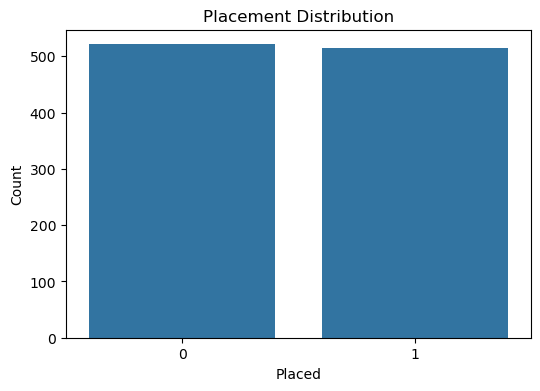

In [15]:
# 11. Target Variable Analysis
# placed: 1 means placed, 0 means not placed
# ============================================================

print("\nPlacement Count:")
print(df["placed"].value_counts())

print("\nPlacement Percentage:")
print(df["placed"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x="placed", data=df)
plt.title("Placement Distribution")
plt.xlabel("Placed")
plt.ylabel("Count")
plt.show()

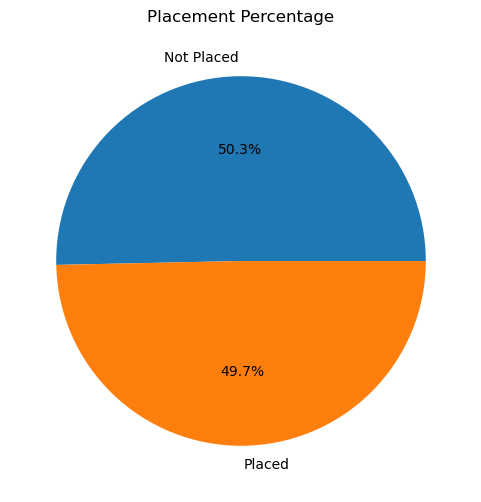

In [16]:
# Pie chart
plt.figure(figsize=(6, 6))
df["placed"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Not Placed", "Placed"]
)
plt.title("Placement Percentage")
plt.ylabel("")
plt.show()

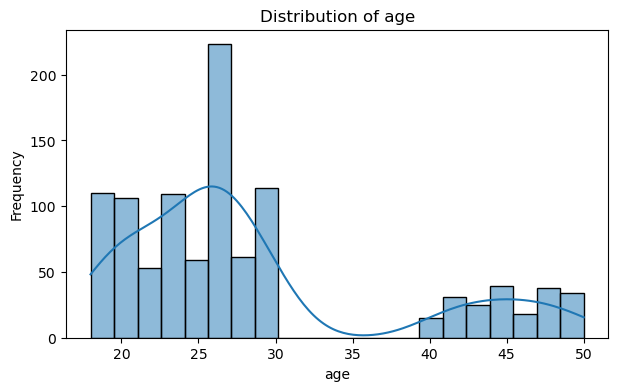

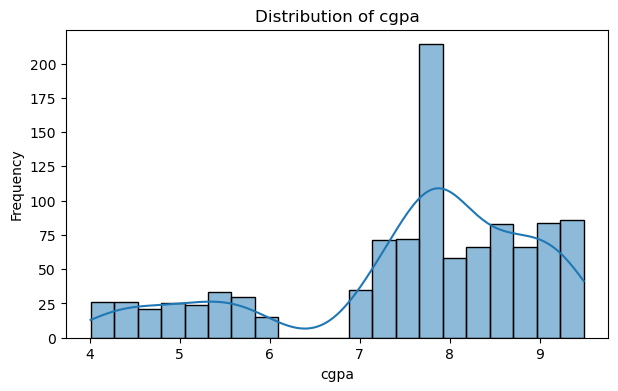

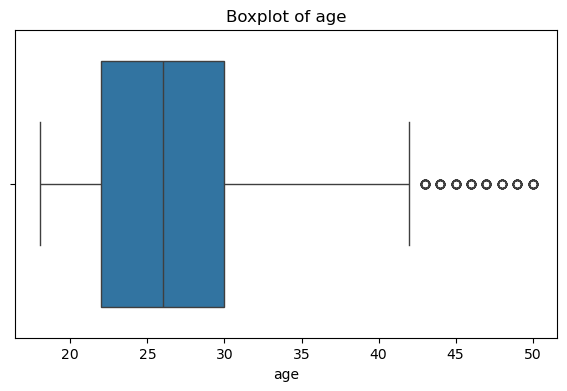

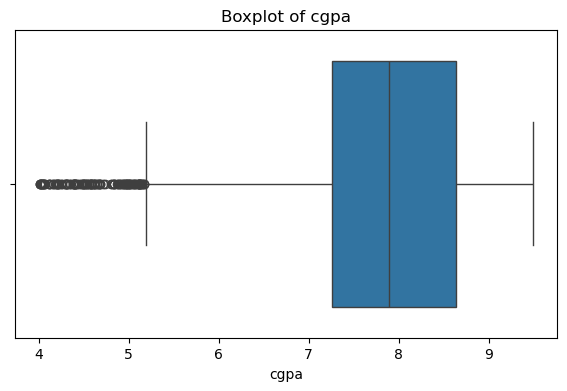

In [17]:
# 12. Numerical Column Analysis
# ============================================================

num_cols = ["age", "cgpa"]

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

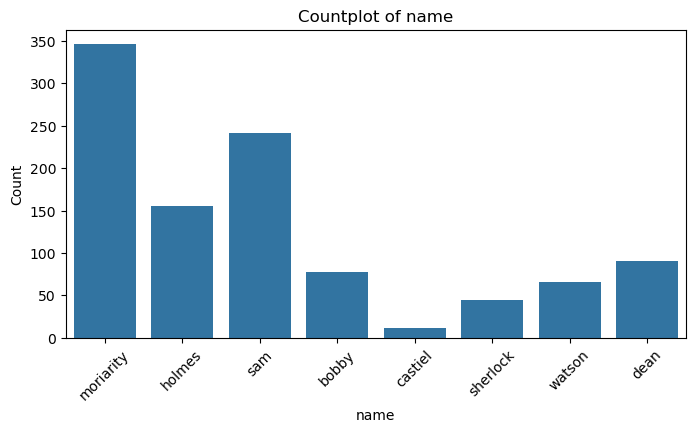

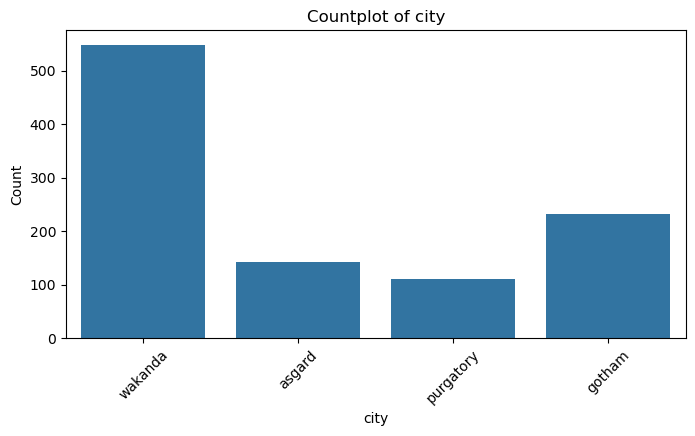

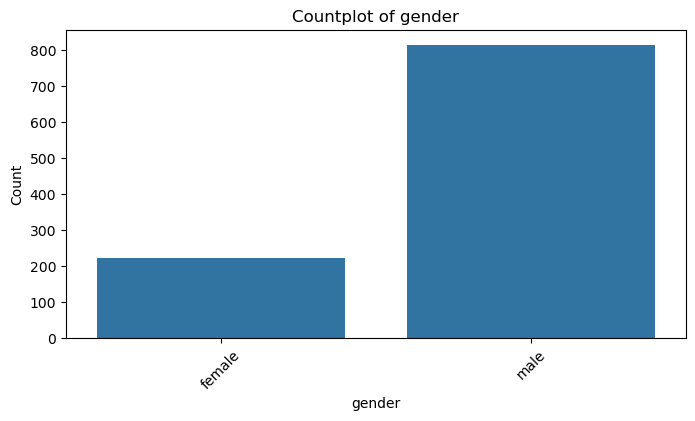

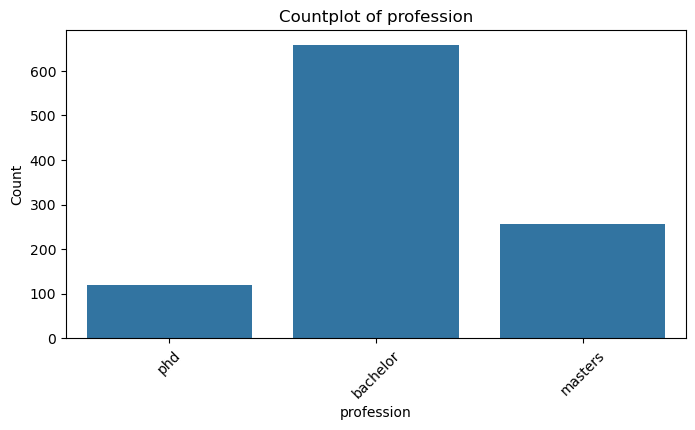

In [18]:
# 13. Categorical Column Analysis
# ============================================================

cat_cols = ["name", "city", "gender", "profession"]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

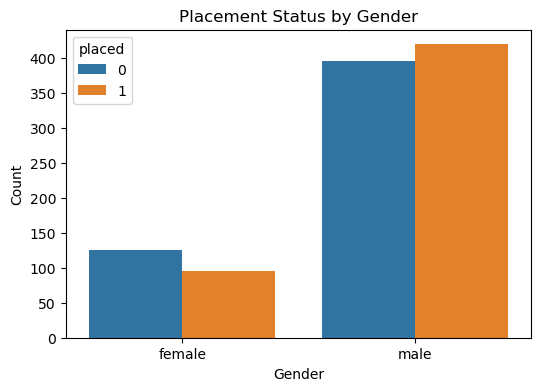


Placement Rate by Gender:
gender
female    42.986425
male      51.474201
Name: placed, dtype: float64


In [19]:
# 14. Placement Analysis by Gender
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(x="gender", hue="placed", data=df)
plt.title("Placement Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

print("\nPlacement Rate by Gender:")
print(df.groupby("gender")["placed"].mean() * 100)

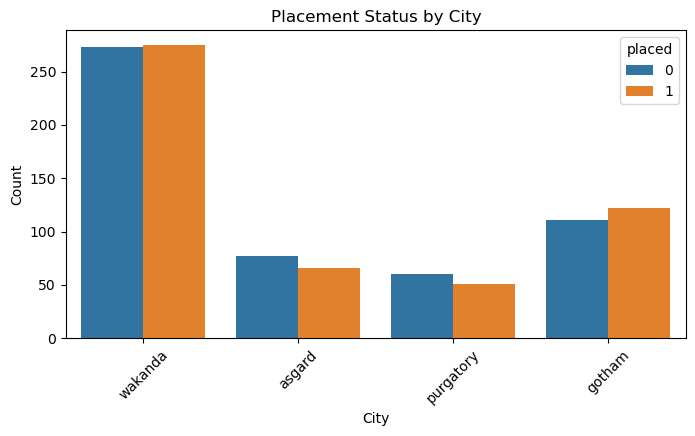


Placement Rate by City:
city
asgard       46.153846
gotham       52.360515
purgatory    45.945946
wakanda      50.182482
Name: placed, dtype: float64


In [20]:
# 15. Placement Analysis by City
# ============================================================

plt.figure(figsize=(8, 4))
sns.countplot(x="city", hue="placed", data=df)
plt.title("Placement Status by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print("\nPlacement Rate by City:")
print(df.groupby("city")["placed"].mean() * 100)

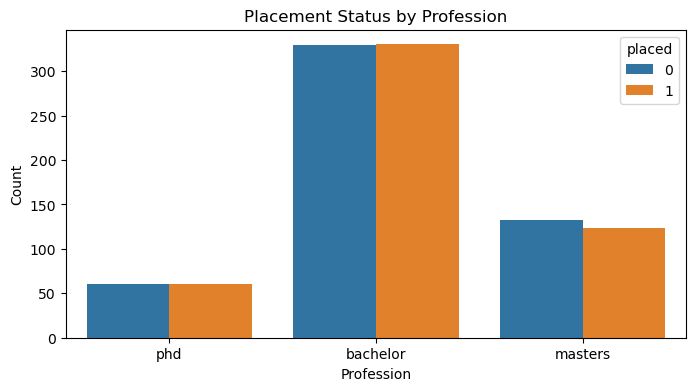


Placement Rate by Profession:
profession
bachelor    50.075873
masters     48.437500
phd         50.000000
Name: placed, dtype: float64


In [21]:
# 16. Placement Analysis by Profession
# ============================================================

plt.figure(figsize=(8, 4))
sns.countplot(x="profession", hue="placed", data=df)
plt.title("Placement Status by Profession")
plt.xlabel("Profession")
plt.ylabel("Count")
plt.show()

print("\nPlacement Rate by Profession:")
print(df.groupby("profession")["placed"].mean() * 100)

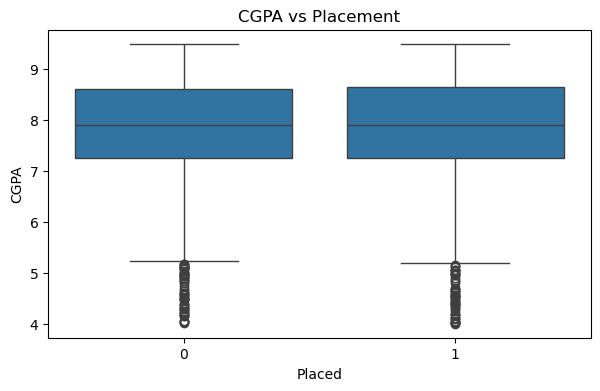

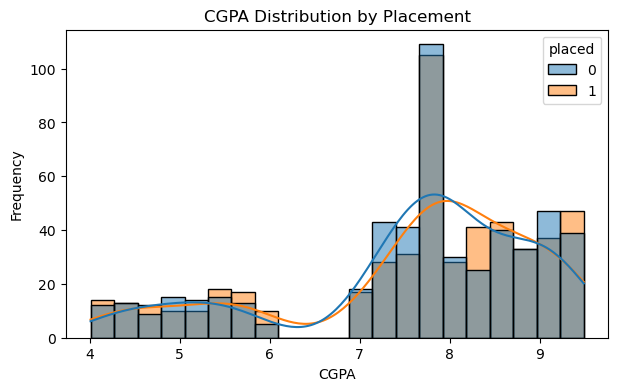


Average CGPA by Placement:
placed
0    7.601190
1    7.611809
Name: cgpa, dtype: float64


In [22]:
# 17. CGPA vs Placement
# ============================================================

plt.figure(figsize=(7, 4))
sns.boxplot(x="placed", y="cgpa", data=df)
plt.title("CGPA vs Placement")
plt.xlabel("Placed")
plt.ylabel("CGPA")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="cgpa", hue="placed", kde=True)
plt.title("CGPA Distribution by Placement")
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

print("\nAverage CGPA by Placement:")
print(df.groupby("placed")["cgpa"].mean())


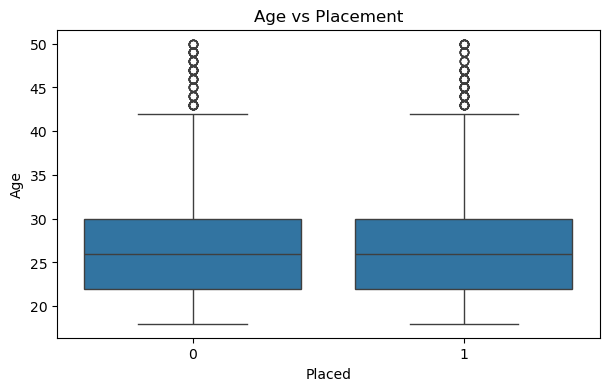

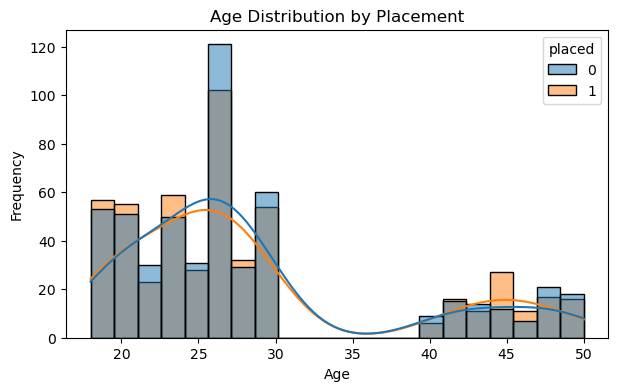


Average Age by Placement:
placed
0    28.278311
1    28.463035
Name: age, dtype: float64


In [23]:
# 18. Age vs Placement
# ============================================================

plt.figure(figsize=(7, 4))
sns.boxplot(x="placed", y="age", data=df)
plt.title("Age vs Placement")
plt.xlabel("Placed")
plt.ylabel("Age")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", hue="placed", kde=True)
plt.title("Age Distribution by Placement")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print("\nAverage Age by Placement:")
print(df.groupby("placed")["age"].mean())

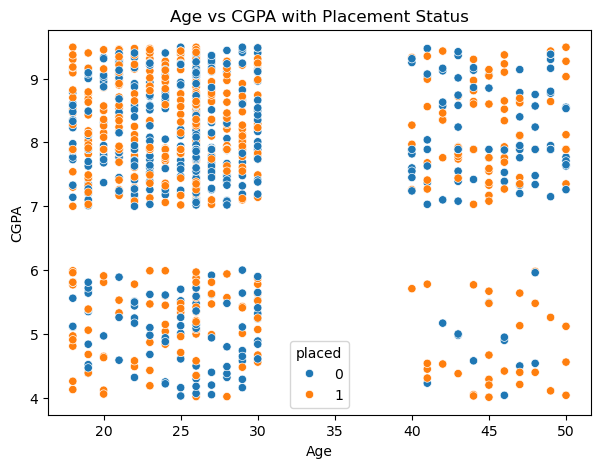

In [24]:
# 19. CGPA vs Age Scatter Plot
# ============================================================

plt.figure(figsize=(7, 5))
sns.scatterplot(x="age", y="cgpa", hue="placed", data=df)
plt.title("Age vs CGPA with Placement Status")
plt.xlabel("Age")
plt.ylabel("CGPA")
plt.show()

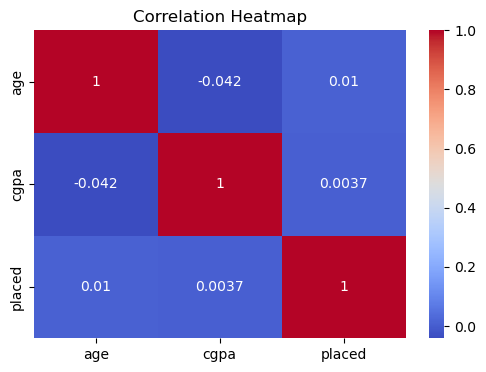


Correlation Matrix:
             age      cgpa    placed
age     1.000000 -0.041570  0.010434
cgpa   -0.041570  1.000000  0.003724
placed  0.010434  0.003724  1.000000


In [25]:
# 20. Correlation Analysis for Numerical Columns
# ============================================================

plt.figure(figsize=(6, 4))
sns.heatmap(df[["age", "cgpa", "placed"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation Matrix:")
print(df[["age", "cgpa", "placed"]].corr())


Encoded Data Sample:
    age  cgpa  placed  name_castiel  name_dean  name_holmes  name_moriarity  \
0  28.0  5.94       1         False      False        False            True   
1  50.0  8.55       0         False      False        False            True   
2  18.0  5.56       0         False      False         True           False   
3  25.0  8.57       1         False      False        False           False   
4  19.0  8.76       1         False      False        False           False   

   name_sam  name_sherlock  name_watson  city_gotham  city_purgatory  \
0     False          False        False        False           False   
1     False          False        False        False           False   
2     False          False        False        False           False   
3      True          False        False        False           False   
4      True          False        False        False           False   

   city_wakanda  gender_male  profession_masters  profession_phd  
0  

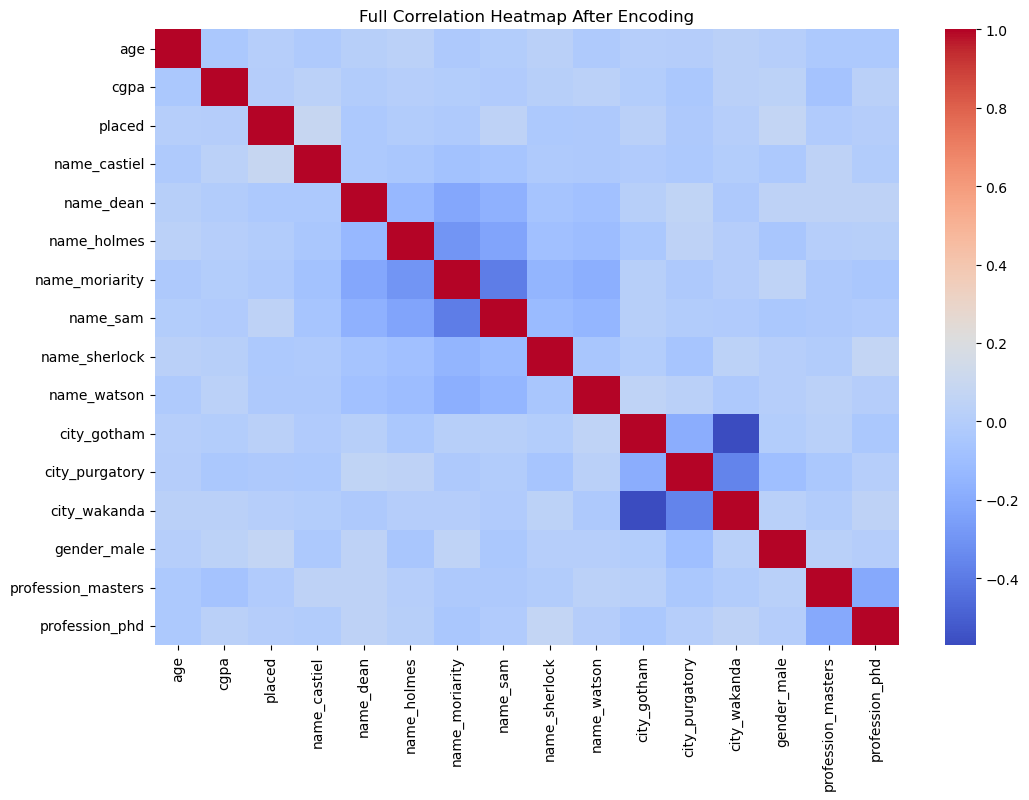

In [26]:
# ============================================================
# 21. Categorical Encoding for Full Correlation
# ============================================================

df_encoded = pd.get_dummies(df, drop_first=True)

print("\nEncoded Data Sample:")
print(df_encoded.head())

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Full Correlation Heatmap After Encoding")
plt.show()


Correlation of Features with Placement:
placed                1.000000
name_castiel          0.090990
gender_male           0.069567
name_sam              0.044826
city_gotham           0.029093
city_wakanda          0.011046
age                   0.010434
cgpa                  0.003724
profession_phd        0.002449
name_holmes          -0.010700
profession_masters   -0.014038
name_moriarity       -0.019785
city_purgatory       -0.025759
name_watson          -0.029870
name_sherlock        -0.031723
name_dean            -0.035432
Name: placed, dtype: float64


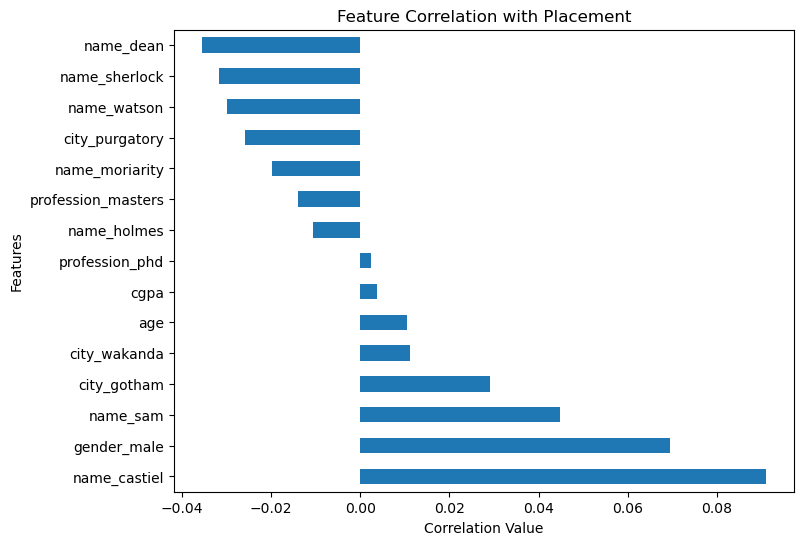

In [27]:
# Correlation of all features with placed
correlation_with_placed = df_encoded.corr()["placed"].sort_values(ascending=False)

print("\nCorrelation of Features with Placement:")
print(correlation_with_placed)

plt.figure(figsize=(8, 6))
correlation_with_placed.drop("placed").plot(kind="barh")
plt.title("Feature Correlation with Placement")
plt.xlabel("Correlation Value")
plt.ylabel("Features")
plt.show()

In [28]:
# 22. Outlier Detection using IQR Method
# ============================================================

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print(f"\nOutliers in {col}:")
    print("Number of Outliers:", len(outliers))
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)


Outliers in age:
Number of Outliers: 154
Lower Limit: 10.0
Upper Limit: 42.0

Outliers in cgpa:
Number of Outliers: 114
Lower Limit: 5.189999999999999
Upper Limit: 10.71



Placement Rate by CGPA Range:
cgpa_range
Below 6    52.000000
6-7        50.000000
7-8        46.341463
8-9        54.230769
9-10       47.852761
Name: placed, dtype: float64


C:\Users\kendr\AppData\Local\Temp\ipykernel_32292\3795101383.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("cgpa_range")["placed"].mean() * 100)


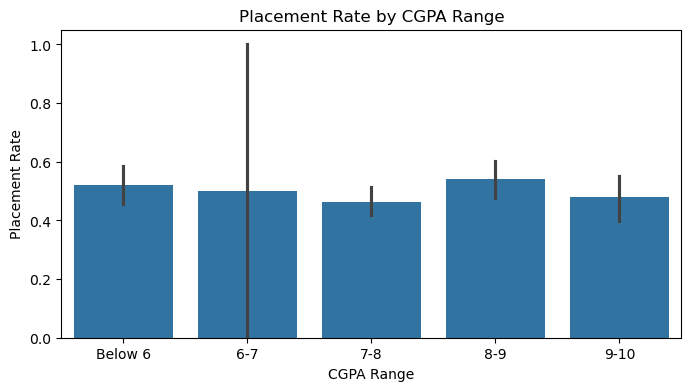

In [29]:
# 23. Placement Rate Based on CGPA Range
# ============================================================

df["cgpa_range"] = pd.cut(
    df["cgpa"],
    bins=[0, 6, 7, 8, 9, 10],
    labels=["Below 6", "6-7", "7-8", "8-9", "9-10"]
)

print("\nPlacement Rate by CGPA Range:")
print(df.groupby("cgpa_range")["placed"].mean() * 100)

plt.figure(figsize=(8, 4))
sns.barplot(x="cgpa_range", y="placed", data=df)
plt.title("Placement Rate by CGPA Range")
plt.xlabel("CGPA Range")
plt.ylabel("Placement Rate")
plt.show()



Placement Rate by Age Group:
age_group
Below 20    51.923077
21-25       50.177936
26-30       47.236181
31-35             NaN
Above 35    52.000000
Name: placed, dtype: float64


C:\Users\kendr\AppData\Local\Temp\ipykernel_32292\2005554501.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("age_group")["placed"].mean() * 100)


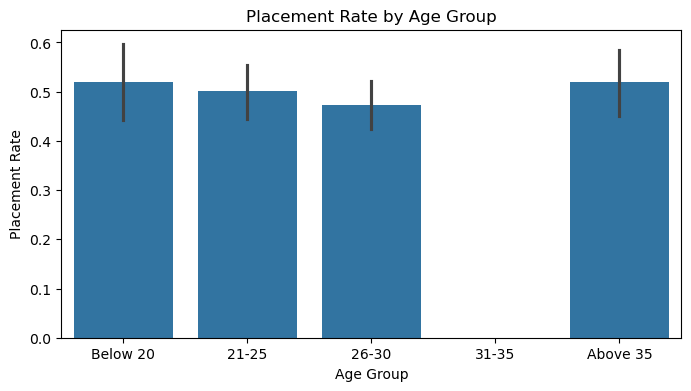

In [30]:
# 24. Placement Rate Based on Age Group
# ============================================================

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 20, 25, 30, 35, 60],
    labels=["Below 20", "21-25", "26-30", "31-35", "Above 35"]
)

print("\nPlacement Rate by Age Group:")
print(df.groupby("age_group")["placed"].mean() * 100)

plt.figure(figsize=(8, 4))
sns.barplot(x="age_group", y="placed", data=df)
plt.title("Placement Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Placement Rate")
plt.show()

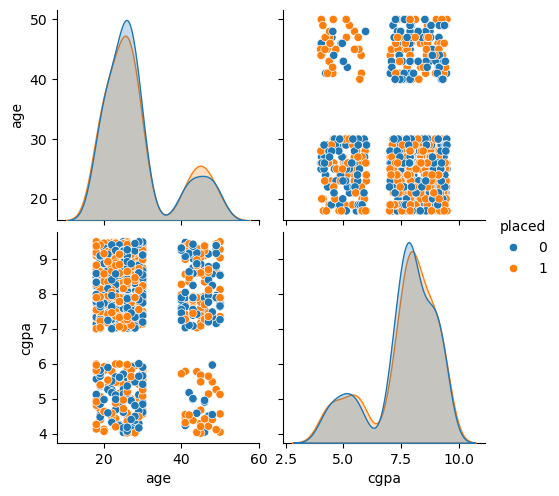

In [31]:
# 25. Pair Plot
# ============================================================

sns.pairplot(df[["age", "cgpa", "placed"]], hue="placed")
plt.show()


Model Accuracy:
0.4927536231884058

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.53      0.50       100
           1       0.51      0.46      0.48       107

    accuracy                           0.49       207
   macro avg       0.49      0.49      0.49       207
weighted avg       0.49      0.49      0.49       207


Confusion Matrix:
[[53 47]
 [58 49]]

Top Important Features:
               Feature  Importance
1                 cgpa    0.312595
0                  age    0.204542
13  profession_masters    0.041364
11        city_wakanda    0.036562
12         gender_male    0.034612
5       name_moriarity    0.034471
9          city_gotham    0.034040
6             name_sam    0.031322
16      cgpa_range_7-8    0.028828
20     age_group_26-30    0.028042


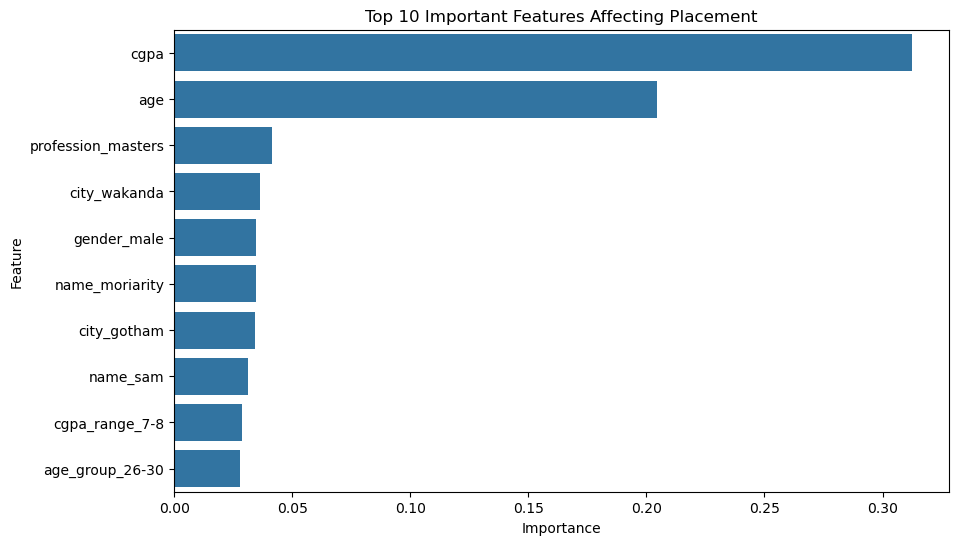

In [32]:
# 26. Key Influencing Factors using Random Forest

# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare data
X = df.drop(["placed"], axis=1)
y = df["placed"]

# Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nModel Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Important Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10))
plt.title("Top 10 Important Features Affecting Placement")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [33]:
# 27. Final Insights
# ============================================================

print("\n================ FINAL EDA INSIGHTS ================")

print("\n1. Dataset contains student-related information such as city, gender, profession, age, CGPA, and placement status.")

print("\n2. Missing values were present in columns like name, city, gender, profession, age, and CGPA.")

print("\n3. Duplicate records were found and removed from the dataset.")

print("\n4. Placement column is the target variable where:")
print("   1 means Placed")
print("   0 means Not Placed")

print("\n5. CGPA is an important numerical factor that may influence placement.")

print("\n6. Gender, city, and profession-wise placement rates help us understand categorical patterns.")

print("\n7. Correlation analysis helps to identify which features are related to placement.")

print("\n8. Random Forest feature importance shows the most influential factors for placement.")

print("\n====================================================")


================ FINAL EDA INSIGHTS ================

1. Dataset contains student-related information such as city, gender, profession, age, CGPA, and placement status.

2. Missing values were present in columns like name, city, gender, profession, age, and CGPA.

3. Duplicate records were found and removed from the dataset.

4. Placement column is the target variable where:
   1 means Placed
   0 means Not Placed

5. CGPA is an important numerical factor that may influence placement.

6. Gender, city, and profession-wise placement rates help us understand categorical patterns.

7. Correlation analysis helps to identify which features are related to placement.

8. Random Forest feature importance shows the most influential factors for placement.

